MEMBER 1: DATA PREPROCESSING & EDA
Current working directory: C:\Users\ASUS\Downloads\assignment (1)
Created folders: results/, data/, models/

STEP 1: LOADING DATA
Dataset loaded successfully!
   Shape: (5110, 12)
   Columns: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

First 5 rows:
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural    

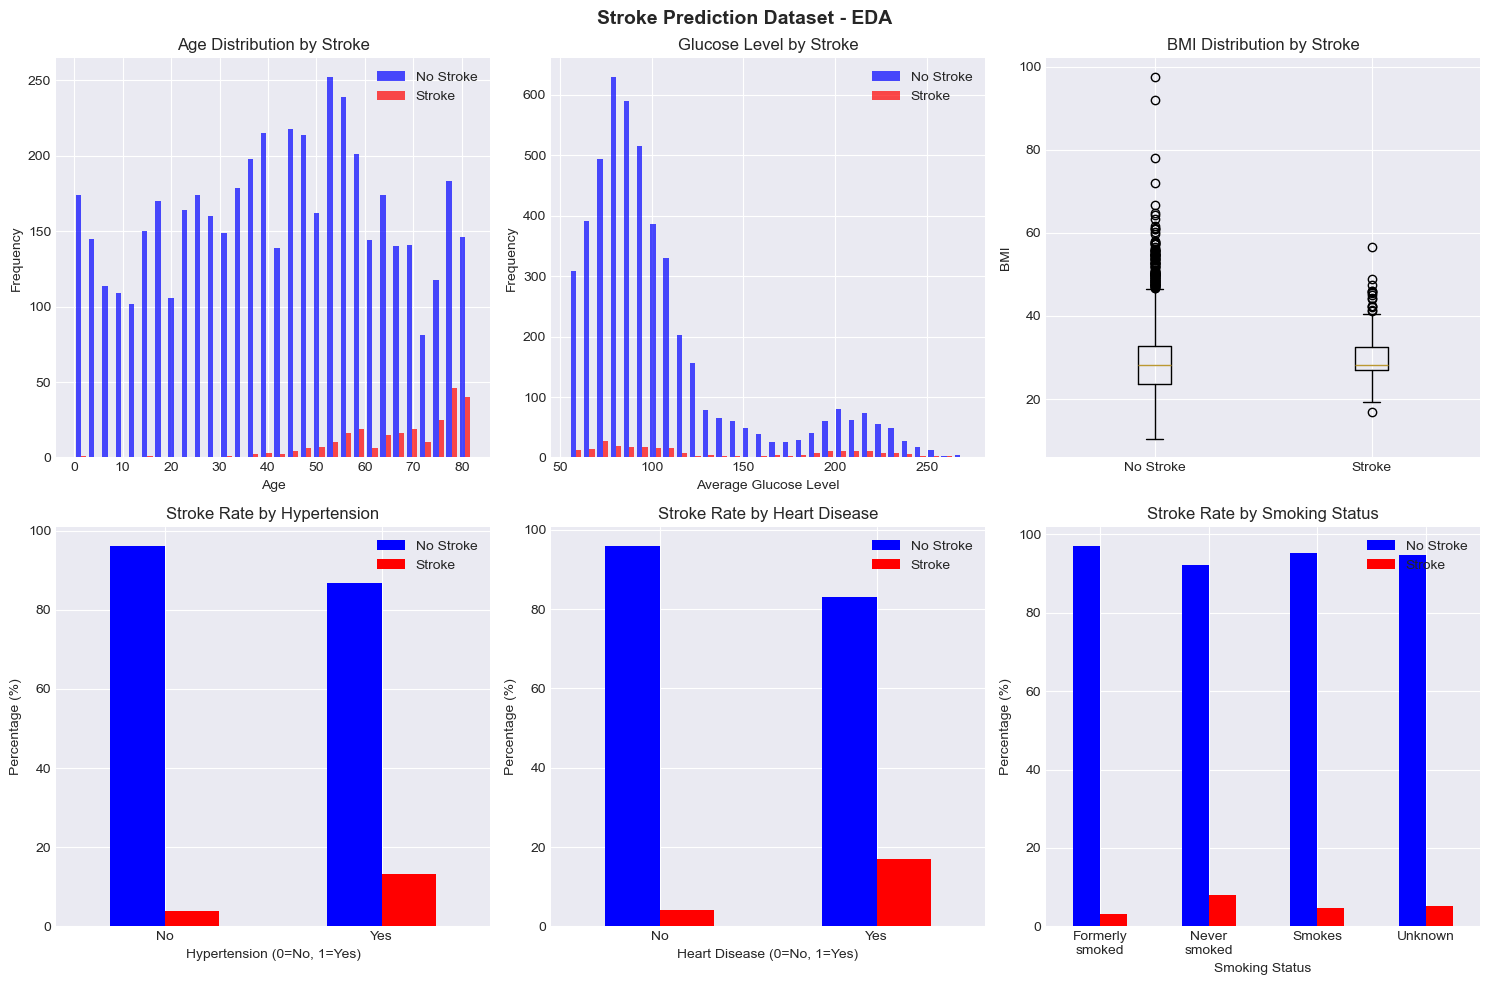

 Saved EDA plots to 'results/eda_plots.png'


<Figure size 1000x600 with 0 Axes>

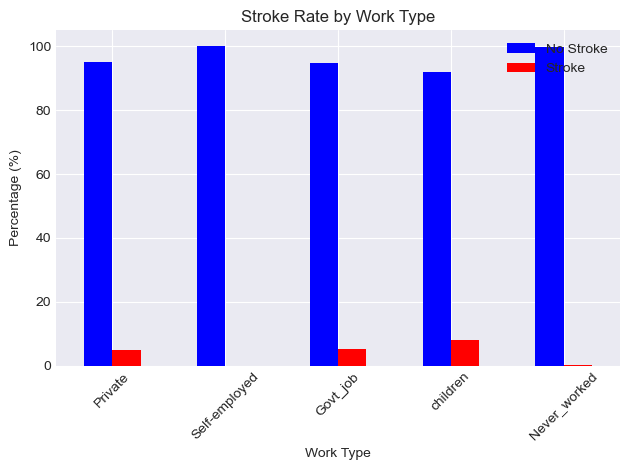

 Saved work type analysis to 'results/work_type_analysis.png'

STEP 8: CORRELATION ANALYSIS


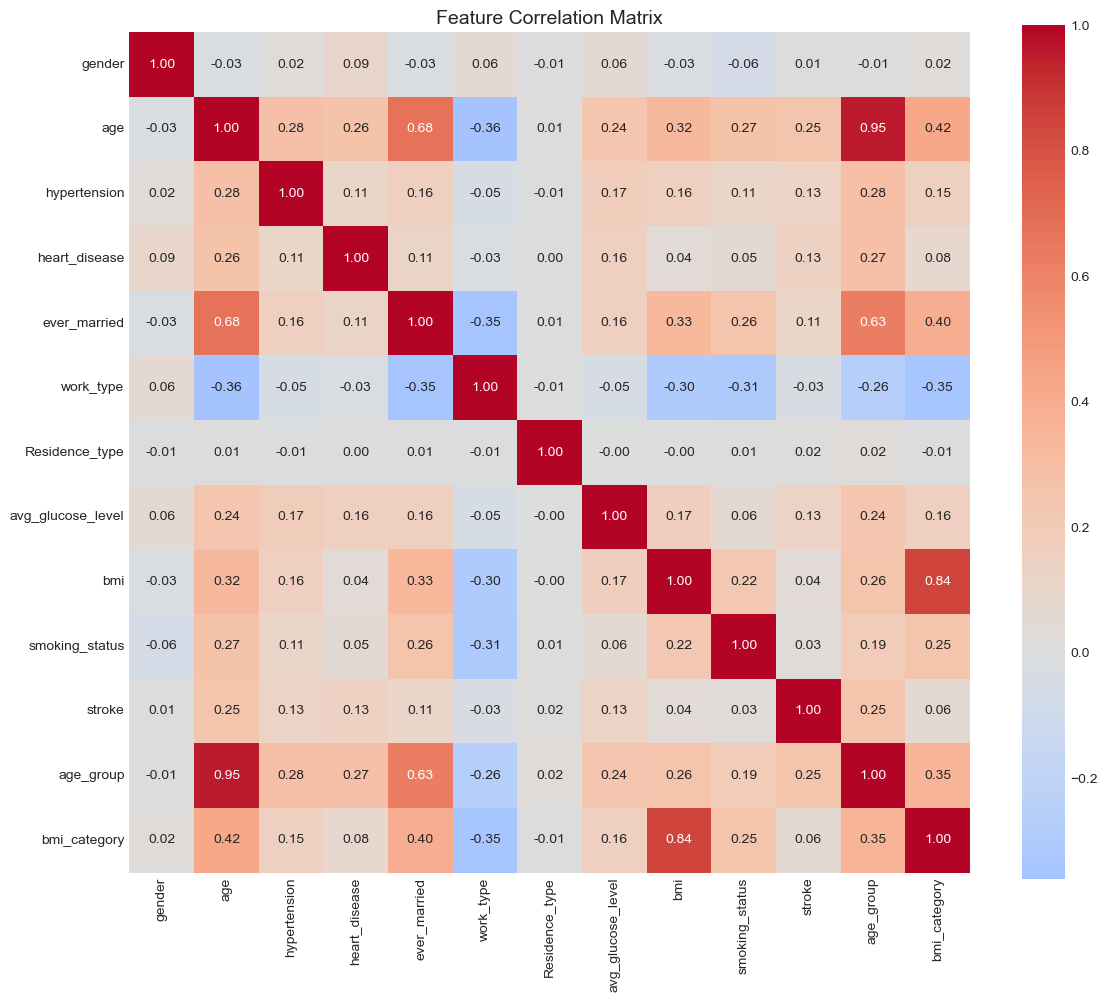

 Saved correlation matrix to 'results/correlation_matrix.png'

Correlation with stroke (target):
  stroke: 1.000
  age_group: 0.253
  age: 0.245
  heart_disease: 0.135
  avg_glucose_level: 0.132
  hypertension: 0.128
  ever_married: 0.108
  bmi_category: 0.059
  bmi: 0.036
  smoking_status: 0.028
  Residence_type: 0.015
  gender: 0.009
  work_type: -0.032

 Top 5 features correlated with stroke:
   → age_group: 0.253
   → age: 0.245
   → heart_disease: 0.135
   → avg_glucose_level: 0.132
   → hypertension: 0.128

STEP 9: SAVING PREPROCESSED DATA
 Preprocessed data saved to 'data/stroke_data_preprocessed.csv'
 Label encoders saved to 'data/label_encoders.pkl'
 Feature list saved to 'data/feature_list.pkl'

MEMBER 1: TASKS COMPLETED ✓

📋 SUMMARY OF WORK COMPLETED:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. DATA LOADING & INSPECTION
   ✓ Loaded dataset with 5110 rows and 13 columns
   ✓ Identified missing values in BMI column
   ✓ Analyzed target distribution (4.9% s

In [9]:
# ============================================
# MEMBER 1: DATA PREPROCESSING & EDA
# Updated with proper file paths and fixes
# ============================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import pickle
import warnings
warnings.filterwarnings('ignore')

# ============================================
# CREATE ALL NECESSARY FOLDERS
# ============================================

# Create folders in current directory (not parent directory)
os.makedirs('results', exist_ok=True)
os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("="*60)
print("MEMBER 1: DATA PREPROCESSING & EDA")
print("="*60)
print(f"Current working directory: {os.getcwd()}")
print("Created folders: results/, data/, models/")

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================
# STEP 1: LOAD DATA
# ============================================

print("\n" + "="*40)
print("STEP 1: LOADING DATA")
print("="*40)

# Load data from current directory
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

print(f"Dataset loaded successfully!")
print(f"   Shape: {df.shape}")
print(f"   Columns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

# ============================================
# STEP 2: INITIAL DATA INSPECTION
# ============================================

print("\n" + "="*40)
print("STEP 2: DATA INSPECTION")
print("="*40)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

print("\nTarget Distribution:")
print(df['stroke'].value_counts())
print(f"Stroke percentage: {df['stroke'].mean()*100:.2f}%")

# ============================================
# STEP 3: HANDLE MISSING VALUES
# ============================================

print("\n" + "="*40)
print("STEP 3: HANDLING MISSING VALUES")
print("="*40)

# Check missing percentage
missing_pct = (df.isnull().sum() / len(df)) * 100
print(f"Missing values percentage:\n{missing_pct}")

# BMI has ~3.9% missing - fill with median
bmi_median = df['bmi'].median()
df['bmi'].fillna(bmi_median, inplace=True)
print(f"\n Filled BMI missing values with median: {bmi_median:.1f}")

# Verify no missing values
print(f"\n Remaining missing values: {df.isnull().sum().sum()}")

# ============================================
# STEP 4: DROP ID COLUMN
# ============================================

print("\n" + "="*40)
print("STEP 4: DROPPING ID COLUMN")
print("="*40)

if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)
    print(" Dropped 'id' column (not useful for prediction)")

# ============================================
# STEP 5: FEATURE ENGINEERING
# ============================================

print("\n" + "="*40)
print("STEP 5: FEATURE ENGINEERING")
print("="*40)

# Create age groups
def age_group(age):
    if age < 30:
        return 0  # Young
    elif age < 50:
        return 1  # Middle
    elif age < 70:
        return 2  # Senior
    else:
        return 3  # Elderly

df['age_group'] = df['age'].apply(age_group)
print(" Created 'age_group' feature")

# Create BMI categories
def bmi_category(bmi):
    if bmi < 18.5:
        return 0  # Underweight
    elif bmi < 25:
        return 1  # Normal
    elif bmi < 30:
        return 2  # Overweight
    else:
        return 3  # Obese

df['bmi_category'] = df['bmi'].apply(bmi_category)
print(" Created 'bmi_category' feature")

# Show distribution of new features
print("\nAge Group Distribution:")
print(df['age_group'].value_counts().sort_index())
print("\nBMI Category Distribution:")
print(df['bmi_category'].value_counts().sort_index())

# ============================================
# STEP 6: ENCODE CATEGORICAL VARIABLES
# ============================================

print("\n" + "="*40)
print("STEP 6: ENCODING CATEGORICAL VARIABLES")
print("="*40)

categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    # Print mapping
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f" {col}: {mapping}")

# ============================================
# STEP 7: EXPLORATORY DATA ANALYSIS
# ============================================

print("\n" + "="*40)
print("STEP 7: EXPLORATORY DATA ANALYSIS")
print("="*40)

# Create EDA plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Stroke Prediction Dataset - EDA', fontsize=14, fontweight='bold')

# 1. Age distribution by stroke
axes[0,0].hist([df[df['stroke']==0]['age'], df[df['stroke']==1]['age']], 
               bins=30, label=['No Stroke', 'Stroke'], alpha=0.7, color=['blue', 'red'])
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Age Distribution by Stroke')
axes[0,0].legend()

# 2. Glucose level by stroke
axes[0,1].hist([df[df['stroke']==0]['avg_glucose_level'], df[df['stroke']==1]['avg_glucose_level']], 
               bins=30, label=['No Stroke', 'Stroke'], alpha=0.7, color=['blue', 'red'])
axes[0,1].set_xlabel('Average Glucose Level')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Glucose Level by Stroke')
axes[0,1].legend()

# 3. BMI by stroke
bp = axes[0,2].boxplot([df[df['stroke']==0]['bmi'], df[df['stroke']==1]['bmi']], 
                       labels=['No Stroke', 'Stroke'])
axes[0,2].set_title('BMI Distribution by Stroke')
axes[0,2].set_ylabel('BMI')

# 4. Hypertension impact
hypertension_stroke = pd.crosstab(df['hypertension'], df['stroke'], normalize='index') * 100
hypertension_stroke.plot(kind='bar', ax=axes[1,0], color=['blue', 'red'], legend=True)
axes[1,0].set_title('Stroke Rate by Hypertension')
axes[1,0].set_ylabel('Percentage (%)')
axes[1,0].set_xlabel('Hypertension (0=No, 1=Yes)')
axes[1,0].set_xticklabels(['No', 'Yes'], rotation=0)
axes[1,0].legend(['No Stroke', 'Stroke'])

# 5. Heart disease impact
heart_stroke = pd.crosstab(df['heart_disease'], df['stroke'], normalize='index') * 100
heart_stroke.plot(kind='bar', ax=axes[1,1], color=['blue', 'red'], legend=True)
axes[1,1].set_title('Stroke Rate by Heart Disease')
axes[1,1].set_ylabel('Percentage (%)')
axes[1,1].set_xlabel('Heart Disease (0=No, 1=Yes)')
axes[1,1].set_xticklabels(['No', 'Yes'], rotation=0)
axes[1,1].legend(['No Stroke', 'Stroke'])

# 6. Smoking status impact
smoking_stroke = pd.crosstab(df['smoking_status'], df['stroke'], normalize='index') * 100
smoking_stroke.plot(kind='bar', ax=axes[1,2], color=['blue', 'red'], legend=True)
axes[1,2].set_title('Stroke Rate by Smoking Status')
axes[1,2].set_ylabel('Percentage (%)')
axes[1,2].set_xlabel('Smoking Status')
# Map encoded values back to original for display
smoking_labels = {0: 'Formerly\nsmoked', 1: 'Never\nsmoked', 2: 'Smokes', 3: 'Unknown'}
axes[1,2].set_xticklabels([smoking_labels.get(i, str(i)) for i in range(4)], rotation=0)
axes[1,2].legend(['No Stroke', 'Stroke'])

plt.tight_layout()
plt.savefig('results/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved EDA plots to 'results/eda_plots.png'")

# Additional EDA: Work type analysis
plt.figure(figsize=(10, 6))
work_stroke = pd.crosstab(df['work_type'], df['stroke'], normalize='index') * 100
work_labels = {0: 'Private', 1: 'Self-employed', 2: 'Govt_job', 3: 'children', 4: 'Never_worked'}
work_stroke.index = [work_labels.get(i, str(i)) for i in work_stroke.index]
work_stroke.plot(kind='bar', color=['blue', 'red'])
plt.title('Stroke Rate by Work Type', fontsize=12)
plt.ylabel('Percentage (%)')
plt.xlabel('Work Type')
plt.legend(['No Stroke', 'Stroke'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('results/work_type_analysis.png', dpi=150)
plt.show()
print(" Saved work type analysis to 'results/work_type_analysis.png'")

# ============================================
# STEP 8: CORRELATION ANALYSIS
# ============================================

print("\n" + "="*40)
print("STEP 8: CORRELATION ANALYSIS")
print("="*40)

# Correlation matrix
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('results/correlation_matrix.png', dpi=150)
plt.show()
print(" Saved correlation matrix to 'results/correlation_matrix.png'")

# Correlation with target
print("\nCorrelation with stroke (target):")
corr_with_target = corr_matrix['stroke'].sort_values(ascending=False)
for feature, corr in corr_with_target.items():
    print(f"  {feature}: {corr:.3f}")

# Identify top correlated features
print("\n Top 5 features correlated with stroke:")
top_features = corr_with_target[1:6]  # exclude stroke itself
for feature, corr in top_features.items():
    print(f"   → {feature}: {corr:.3f}")

# ============================================
# STEP 9: SAVE PREPROCESSED DATA
# ============================================

print("\n" + "="*40)
print("STEP 9: SAVING PREPROCESSED DATA")
print("="*40)

# Save to data folder
df.to_csv('data/stroke_data_preprocessed.csv', index=False)
print(" Preprocessed data saved to 'data/stroke_data_preprocessed.csv'")

# Save label encoders for other members
with open('data/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print(" Label encoders saved to 'data/label_encoders.pkl'")

# Save feature list for reference
feature_list = list(df.columns)
with open('data/feature_list.pkl', 'wb') as f:
    pickle.dump(feature_list, f)
print(" Feature list saved to 'data/feature_list.pkl'")

# ============================================
# STEP 10: FINAL SUMMARY
# ============================================

print("\n" + "="*60)
print("MEMBER 1: TASKS COMPLETED ✓")
print("="*60)

print("""
📋 SUMMARY OF WORK COMPLETED:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. DATA LOADING & INSPECTION
   ✓ Loaded dataset with {0} rows and {1} columns
   ✓ Identified missing values in BMI column
   ✓ Analyzed target distribution ({2:.1f}% stroke cases)

2. DATA CLEANING
   ✓ Filled missing BMI values with median ({3:.1f})
   ✓ Dropped ID column (not useful for prediction)

3. FEATURE ENGINEERING
   ✓ Created 'age_group' (4 categories)
   ✓ Created 'bmi_category' (4 categories)

4. CATEGORICAL ENCODING
   ✓ Encoded {4} categorical variables
   ✓ Saved label encoders for consistency

5. EXPLORATORY DATA ANALYSIS
   ✓ Generated 8+ visualization plots
   ✓ Created correlation matrix
   ✓ Identified key predictors: age, glucose, hypertension

6. OUTPUT FILES CREATED
   ✓ data/stroke_data_preprocessed.csv
   ✓ data/label_encoders.pkl
   ✓ data/feature_list.pkl
   ✓ results/eda_plots.png
   ✓ results/correlation_matrix.png
   ✓ results/work_type_analysis.png

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📌 NEXT STEPS FOR OTHER MEMBERS:
   • Member 2: Load data from 'data/stroke_data_preprocessed.csv'
   • Member 3: Use same file for Random Forest & SVM
   • Member 4: Load results from all members for comparison

""".format(df.shape[0], df.shape[1], df['stroke'].mean()*100, bmi_median, len(categorical_cols)))

print("\n ALL DONE! Ready for Member 2, 3, and 4 to proceed.")